# 03 RAGAS Generation Evaluation

Notebook này dùng cùng 6 retrieval methods từ notebook 02, generate answer cho từng method, rồi chọn pipeline chính bằng `generation_score` từ RAGAS generation metrics.

Retrieval metrics chỉ dùng để giải thích vì sao một method trả lời tốt hoặc kém; chúng không tham gia vào `generation_score`.


In [1]:
from __future__ import annotations

import hashlib
import json
import math
import os
import re
import time
import warnings
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datasets import Dataset
from dotenv import load_dotenv
from IPython.display import Markdown, display
from ragas import evaluate
from ragas.run_config import RunConfig


def find_project_root() -> Path:
    cwd = Path.cwd()
    if (cwd / "notebooks").exists() and (cwd / "reports").exists():
        return cwd
    if cwd.name == "notebooks":
        return cwd.parent
    return cwd


PROJECT_ROOT = find_project_root()
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"
RETRIEVAL_JSON = REPORTS_DIR / "retrieval_evaluation.json"
RAGAS_QUESTIONS_JSON = REPORTS_DIR / "ragas_questions.json"
RAG_ANSWERS_JSON = REPORTS_DIR / "rag_answers.json"
RAGAS_EVAL_JSON = REPORTS_DIR / "ragas_evaluation.json"
RAGAS_EVAL_MD = REPORTS_DIR / "ragas_evaluation.md"
PROGRESS_DIR = PROJECT_ROOT / ".tmp/ragas_progress"

REPORTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)
PROGRESS_DIR.mkdir(parents=True, exist_ok=True)
load_dotenv(PROJECT_ROOT / ".env")

DEFAULT_MODEL = os.getenv("GEMINI_MODEL", "gemini-3.1-flash-lite")
DEFAULT_EMBEDDING_MODEL = "models/gemini-embedding-001"
RAGAS_RPM_PER_KEY = 12
EVALUATION_VERSION = "ragas_generation_selection_v2"
RAGAS_CONTEXT_MAX_CHARS = 1200
GENERATION_METRICS = ["faithfulness", "answer_relevancy", "answer_correctness"]
DIAGNOSTIC_CONTEXT_METRICS = ["context_precision", "context_recall"]


def sanitize(value):
    if isinstance(value, dict):
        return {key: sanitize(item) for key, item in value.items()}
    if isinstance(value, list):
        return [sanitize(item) for item in value]
    if isinstance(value, tuple):
        return [sanitize(item) for item in value]
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating,)):
        if math.isnan(float(value)):
            return None
        return float(value)
    if pd.isna(value) if not isinstance(value, (str, bytes, dict, list, tuple)) else False:
        return None
    return value


def gemini_keys() -> list[str]:
    raw = ",".join([
        os.getenv("GEMINI_API_KEY") or "",
        os.getenv("GEMINI_API_KEYS") or "",
    ])
    keys = []
    for item in re.split(r"[,;\n]+", raw):
        item = item.strip()
        if item and item not in keys:
            keys.append(item)
    return keys


def is_quota_error(error: Exception) -> bool:
    text = str(error).lower()
    return any(term in text for term in ["quota", "rate limit", "resource_exhausted", "429"])


class BatchGeminiClient:
    def __init__(self, api_keys: list[str], model: str = DEFAULT_MODEL, rpm_limit: int = RAGAS_RPM_PER_KEY):
        if not api_keys:
            raise ValueError("Set GEMINI_API_KEY or GEMINI_API_KEYS")
        from google import genai

        self.api_keys = api_keys
        self.model = model
        self.clients = {key: genai.Client(api_key=key) for key in api_keys}
        self.sleep_seconds = 60 / max(1, rpm_limit)
        self.last_request_at = {key: 0.0 for key in api_keys}
        self.next_key_idx = 0

    def generate(self, prompt: str) -> str:
        last_error = None
        for _ in range(len(self.api_keys)):
            key = self.api_keys[self.next_key_idx % len(self.api_keys)]
            self.next_key_idx += 1
            try:
                self._wait(key)
                response = self.clients[key].models.generate_content(model=self.model, contents=prompt)
                text = (getattr(response, "text", "") or "").strip()
                if text:
                    return text
            except Exception as error:
                last_error = error
                if not is_quota_error(error):
                    raise
        raise RuntimeError(f"Gemini generation failed for available keys: {last_error}")

    def _wait(self, key: str) -> None:
        elapsed = time.time() - self.last_request_at[key]
        wait_seconds = self.sleep_seconds - elapsed
        if wait_seconds > 0:
            time.sleep(wait_seconds)
        self.last_request_at[key] = time.time()


def text_signature(value: object) -> str:
    raw = json.dumps(value, ensure_ascii=False, sort_keys=True)
    return hashlib.sha1(raw.encode("utf-8")).hexdigest()[:16]


retrieval_report = json.loads(RETRIEVAL_JSON.read_text(encoding="utf-8"))
question_meta = json.loads(RAGAS_QUESTIONS_JSON.read_text(encoding="utf-8"))
questions = question_meta["items"]
methods = retrieval_report["methods"]
method_labels = retrieval_report.get("method_labels", {method: method for method in methods})
retrieval_summary = retrieval_report["summary"]
retrieval_details = retrieval_report["details"]
retrieval_by_method = {row["method"]: row for row in retrieval_summary}
detail_by_key = {(row["method"], row["question_id"]): row for row in retrieval_details}

SIGNATURE = text_signature({
    "version": EVALUATION_VERSION,
    "model": DEFAULT_MODEL,
    "methods": methods,
    "retrieval_eval_version": retrieval_report.get("evaluation_version"),
    "details_hash": text_signature([
        {
            "method": row["method"],
            "question_id": row["question_id"],
            "chunks": [result["chunk_id"] for result in row["results"]],
        }
        for row in retrieval_details
    ]),
})

display(pd.DataFrame([{
    "methods": len(methods),
    "questions": len(questions),
    "planned_answers": len(methods) * len(questions),
    "gemini_model": DEFAULT_MODEL,
    "signature": SIGNATURE,
}]))


C:\Users\Acer Nitro\.cache\codex-runtimes\codex-primary-runtime\dependencies\python\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,methods,questions,planned_answers,gemini_model,signature
0,6,30,180,gemini-3.1-flash-lite,6f8eddde71a439fd


## 1. Methods Under Generation Test

Notebook 03 evaluates the same retrieval cases from notebook 02. Each method receives the same questions and prompt format, so the comparison focuses on answer quality.


In [2]:
method_overview = pd.DataFrame([
    {
        "method": method,
        "display_name": method_labels.get(method, method),
        "retrieval_score": retrieval_by_method[method].get("retrieval_score"),
        "mrr": retrieval_by_method[method].get("mrr"),
        "ndcg@5": retrieval_by_method[method].get("ndcg@5"),
    }
    for method in methods
])
display(method_overview)


,method,display_name,retrieval_score,mrr,ndcg@5
0,bm25,BM25,0.889148,1.000000,0.965627
1,vector,Vector,0.881599,0.977778,0.960940
2,hybrid,Hybrid,0.892874,1.000000,0.972680
3,hybrid_rrf,Hybrid + RRF,0.890059,1.000000,0.957307
4,hybrid_rrf_cross_encoder,Hybrid + RRF + Cross-Encoder,0.894474,1.000000,0.969921
5,hybrid_rrf_cross_encoder_mmr,Hybrid + RRF + Cross-Encoder + MMR,0.894056,1.000000,0.970685


### BM25
Keyword-only retrieval. It is a useful legal baseline because many questions contain exact statutory terms.

### Vector
Dense semantic retrieval. It tests whether semantic matching improves answer context when wording differs.

### Hybrid
Weighted combination of BM25 and dense vector scores.

### Hybrid + RRF
Rank fusion version of hybrid retrieval.

### Hybrid + RRF + Cross-Encoder
Adds a stronger local reranker before answer generation.

### Hybrid + RRF + Cross-Encoder + MMR
Adds diversity after reranking to reduce repeated contexts.


## 2. Generate or Load Candidate Answers

Answers are cached by method, question, model, and retrieved chunk signature. Missing answers are generated with Gemini using a conservative `12 RPM/key` limit.


In [3]:
def build_context(results: list[dict], max_chars: int = 9000) -> tuple[str, list[dict]]:
    blocks, citations = [], []
    used = 0
    for idx, result in enumerate(results, start=1):
        label = f"S{idx}"
        title = result.get("title") or "Untitled legal document"
        article = f" / {result['article']}" if result.get("article") else ""
        text = result.get("text") or ""
        block = f"[{label}] {title}{article}\n{text}"
        if used + len(block) > max_chars and blocks:
            break
        used += len(block)
        blocks.append(block)
        citations.append({
            "label": label,
            "chunk_id": result.get("chunk_id"),
            "title": title,
            "article": result.get("article"),
            "source_url": result.get("source_url"),
            "rank": result.get("rank"),
        })
    return "\n\n".join(blocks), citations


def build_prompt(question: str, results: list[dict]) -> tuple[str, list[dict], list[str]]:
    context, citations = build_context(results)
    prompt = f"""Bạn là trợ lý RAG về pháp luật lao động Việt Nam.
Chỉ trả lời dựa trên phần NGỮ CẢNH.
Nếu ngữ cảnh không đủ, hãy nói rõ là chưa đủ căn cứ từ tài liệu được truy xuất.
Trả lời ngắn gọn, có dẫn nguồn dạng [S1], [S2] khi dùng thông tin.

NGỮ CẢNH:
{context}

CÂU HỎI:
{question}

TRẢ LỜI:"""
    return prompt, citations, [result.get("text") or "" for result in results]


def answer_cache_key(method: str, item: dict, results: list[dict]) -> str:
    return text_signature({
        "signature": SIGNATURE,
        "method": method,
        "question_id": item["id"],
        "chunks": [result.get("chunk_id") for result in results],
    })


def load_answer_cache() -> dict[str, dict]:
    if not RAG_ANSWERS_JSON.exists():
        return {}
    payload = json.loads(RAG_ANSWERS_JSON.read_text(encoding="utf-8"))
    if isinstance(payload, dict):
        return {row.get("cache_key"): row for row in payload.get("answers", []) if row.get("cache_key")}
    if isinstance(payload, list):
        return {row.get("cache_key"): row for row in payload if row.get("cache_key")}
    return {}


answer_cache = load_answer_cache()
keys = gemini_keys()
client = BatchGeminiClient(keys) if keys else None
answer_rows, new_answers = [], 0

for method in methods:
    for item in questions:
        detail = detail_by_key[(method, item["id"])]
        results = detail["results"]
        prompt, citations, contexts = build_prompt(item["question"], results)
        cache_key = answer_cache_key(method, item, results)
        cached = answer_cache.get(cache_key)
        if cached:
            answer = cached["answer"]
            answer_cached = True
        else:
            if client is None:
                raise RuntimeError("Gemini key is required when candidate answer cache is missing.")
            answer = client.generate(prompt)
            answer_cached = False
            new_answers += 1
        answer_rows.append({
            "cache_key": cache_key,
            "id": item["id"],
            "question": item["question"],
            "reference": item["reference"],
            "retrieval_method": method,
            "retrieval_display_name": method_labels.get(method, method),
            "answer": answer,
            "contexts": contexts,
            "citations": citations,
            "answer_cached": answer_cached,
            "answer_backend": "gemini",
            "model": DEFAULT_MODEL,
        })

RAG_ANSWERS_JSON.write_text(json.dumps({
    "evaluation_version": EVALUATION_VERSION,
    "signature": SIGNATURE,
    "model": DEFAULT_MODEL,
    "methods": methods,
    "answers": sanitize(answer_rows),
}, ensure_ascii=False, indent=2), encoding="utf-8")

display(pd.DataFrame([{
    "answer_rows": len(answer_rows),
    "cached_answers": sum(1 for row in answer_rows if row["answer_cached"]),
    "new_answers": new_answers,
    "methods": ", ".join(methods),
}]))


,answer_rows,cached_answers,new_answers,methods
0,180,180,0,"bm25, vector, hybrid, hybrid_rrf, hybrid_rrf_c..."


## 3. RAGAS Generation Metrics

RAGAS evaluates generated answers. `faithfulness`, `answer_relevancy`, and `answer_correctness` determine `generation_score`. Context precision/recall are diagnostic only.


In [4]:
def load_cached_ragas_report() -> dict:
    if not RAGAS_EVAL_JSON.exists():
        return {}
    data = json.loads(RAGAS_EVAL_JSON.read_text(encoding="utf-8"))
    return data if isinstance(data, dict) else {}


def select_available_key(keys: list[str], offset: int = 0) -> str:
    from google import genai

    ordered = keys[offset:] + keys[:offset]
    for key in ordered:
        try:
            client = genai.Client(api_key=key)
            response = client.models.generate_content(model=DEFAULT_MODEL, contents="Return exactly: OK")
            if (getattr(response, "text", "") or "").strip():
                return key
        except Exception:
            continue
    raise RuntimeError("No Gemini key has available quota for RAGAS metrics.")


def build_llm_and_embeddings(api_key: str):
    from langchain_core.rate_limiters import InMemoryRateLimiter
    from langchain_google_genai import ChatGoogleGenerativeAI, GoogleGenerativeAIEmbeddings

    os.environ["GOOGLE_API_KEY"] = api_key
    rate_limiter = InMemoryRateLimiter(
        requests_per_second=RAGAS_RPM_PER_KEY / 60,
        check_every_n_seconds=0.25,
        max_bucket_size=1,
    )
    return (
        ChatGoogleGenerativeAI(
            model=DEFAULT_MODEL,
            google_api_key=api_key,
            temperature=0,
            timeout=120,
            max_retries=0,
            rate_limiter=rate_limiter,
        ),
        GoogleGenerativeAIEmbeddings(model=DEFAULT_EMBEDDING_MODEL, google_api_key=api_key),
    )


def ragas_metric_objects():
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", DeprecationWarning)
        from ragas.metrics import answer_correctness, answer_relevancy, faithfulness
    answer_relevancy.strictness = 1
    return [faithfulness, answer_relevancy, answer_correctness]


def trim_contexts(contexts: list[str], max_chars: int = RAGAS_CONTEXT_MAX_CHARS) -> list[str]:
    return [(context or "")[:max_chars] for context in contexts]


cached_report = load_cached_ragas_report()
valid_cache = (
    cached_report.get("evaluation_version") == EVALUATION_VERSION
    and cached_report.get("answer_signature") == SIGNATURE
    and cached_report.get("answer_count") == len(answer_rows)
    and set(cached_report.get("retrieval_methods_evaluated", [])) == set(methods)
    and cached_report.get("ragas_context_max_chars") == RAGAS_CONTEXT_MAX_CHARS
)

if valid_cache and cached_report.get("details"):
    details = cached_report["details"]
    aggregate_by_method = cached_report["aggregate_by_method"]
    metric_valid_counts = cached_report.get("metric_valid_counts", {})
    if not metric_valid_counts:
        cached_frame = pd.DataFrame(details)
        for method, group in cached_frame.groupby("retrieval_method"):
            metric_valid_counts[method] = {
                metric: int(group[metric].notna().sum()) if metric in group else 0
                for metric in GENERATION_METRICS + DIAGNOSTIC_CONTEXT_METRICS
            }
    unavailable_metrics = cached_report.get("unavailable_metrics", [])
    metrics_cached = True
else:
    keys = gemini_keys()
    if not keys:
        raise RuntimeError("Gemini key is required when cached RAGAS metrics are missing.")
    run_config = RunConfig(timeout=120, max_retries=0, max_wait=2, max_workers=1)

    def evaluate_one_method(method_idx: int, method: str) -> tuple[pd.DataFrame, list[str]]:
        method_answers = [row for row in answer_rows if row["retrieval_method"] == method]
        api_key = select_available_key(keys, offset=method_idx % len(keys))
        llm, embeddings = build_llm_and_embeddings(api_key)
        local_unavailable = []
        metric_objects = ragas_metric_objects()
        rows = []
        progress_path = PROGRESS_DIR / f"{method}.json"

        for idx, row in enumerate(method_answers, start=1):
            eval_row = {
                "user_input": row["question"],
                "response": row["answer"],
                "retrieved_contexts": trim_contexts(row["contexts"]),
                "reference": row["reference"],
            }
            output_row = {
                **eval_row,
                "retrieval_method": row["retrieval_method"],
                "retrieval_display_name": row["retrieval_display_name"],
                "question_id": row["id"],
            }
            try:
                result = evaluate(
                    dataset=Dataset.from_list([eval_row]),
                    metrics=metric_objects,
                    llm=llm,
                    embeddings=embeddings,
                    run_config=run_config,
                    show_progress=False,
                )
                metric_frame = result.to_pandas()
                for metric in GENERATION_METRICS:
                    if metric in metric_frame:
                        output_row[metric] = metric_frame.iloc[0][metric]
            except Exception as error:
                local_unavailable.extend(GENERATION_METRICS)
                print(f"skip {method}/{row['id']}: {type(error).__name__}")
                if is_quota_error(error):
                    rows.append(output_row)
                    break
            for metric in metric_objects:
                value = output_row.get(metric.name)
                if value is not None and not pd.isna(value):
                    continue
                try:
                    retry_result = evaluate(
                        dataset=Dataset.from_list([eval_row]),
                        metrics=[metric],
                        llm=llm,
                        embeddings=embeddings,
                        run_config=run_config,
                        show_progress=False,
                    )
                    retry_frame = retry_result.to_pandas()
                    if metric.name in retry_frame:
                        output_row[metric.name] = retry_frame.iloc[0][metric.name]
                except Exception as error:
                    local_unavailable.append(metric.name)
                    print(f"skip {method}/{row['id']}/{metric.name}: {type(error).__name__}")
                    if is_quota_error(error):
                        break
            rows.append(output_row)
            progress_path.write_text(json.dumps({"method": method, "done": idx, "total": len(method_answers)}, ensure_ascii=False), encoding="utf-8")
        return pd.DataFrame(rows), local_unavailable

    all_frames, unavailable_metrics = [], []
    max_workers = min(len(keys), len(methods))
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = {
            executor.submit(evaluate_one_method, method_idx, method): method
            for method_idx, method in enumerate(methods)
        }
        for future in as_completed(futures):
            method_frame, method_unavailable = future.result()
            all_frames.append(method_frame)
            unavailable_metrics.extend(method_unavailable)

    frame = pd.concat(all_frames, ignore_index=True)
    details = sanitize(frame.to_dict("records"))
    aggregate_by_method = {}
    metric_valid_counts = {}
    for method, group in frame.groupby("retrieval_method"):
        aggregate_by_method[method] = {}
        metric_valid_counts[method] = {}
        for metric in GENERATION_METRICS + DIAGNOSTIC_CONTEXT_METRICS:
            metric_valid_counts[method][metric] = int(group[metric].notna().sum()) if metric in group else 0
            if metric in group and pd.notna(group[metric]).any():
                aggregate_by_method[method][metric] = float(group[metric].mean())
    unavailable_metrics = sorted(set(unavailable_metrics) | {
        metric
        for metric in GENERATION_METRICS
        if all(metric not in scores for scores in aggregate_by_method.values())
    })
    metrics_cached = False

pd.DataFrame(aggregate_by_method).T


,faithfulness,answer_relevancy,answer_correctness
bm25,0.875000,0.533309,0.322595
hybrid,0.713228,0.553112,0.434362
hybrid_rrf,0.770833,0.582281,0.500099
hybrid_rrf_cross_encoder,0.714286,0.489861,0.343912
hybrid_rrf_cross_encoder_mmr,0.870370,0.519042,0.474131
vector,0.888889,0.334253,0.352997


## 4. Generation Comparison and Final Selection

The selected method is the one with the highest `generation_score`. Retrieval scores are shown only as explanation columns.


In [5]:
def generation_score(metrics: dict) -> float | None:
    required = GENERATION_METRICS
    if not all(metric in metrics and metrics[metric] is not None for metric in required):
        return None
    return (
        0.40 * metrics["faithfulness"]
        + 0.30 * metrics["answer_relevancy"]
        + 0.30 * metrics["answer_correctness"]
    )


selection_rows = []
for method in methods:
    metrics = aggregate_by_method.get(method, {})
    row = {
        "method": method,
        "display_name": method_labels.get(method, method),
        "retrieval_score": retrieval_by_method.get(method, {}).get("retrieval_score"),
        "generation_score": generation_score(metrics),
        **{metric: metrics.get(metric) for metric in GENERATION_METRICS + DIAGNOSTIC_CONTEXT_METRICS},
    }
    selection_rows.append(row)

selection_df = pd.DataFrame(selection_rows)
if selection_df["generation_score"].notna().any():
    selection_df = selection_df.sort_values(["generation_score", "faithfulness", "answer_correctness"], ascending=False)
else:
    selection_df = selection_df.sort_values("retrieval_score", ascending=False)
selected_method = selection_df.iloc[0]["method"]

ragas_report = {
    "backend": "ragas_evaluate",
    "evaluation_version": EVALUATION_VERSION,
    "answer_signature": SIGNATURE,
    "answer_count": len(answer_rows),
    "answers_cached": all(row["answer_cached"] for row in answer_rows),
    "metrics_cached": metrics_cached,
    "retrieval_methods_evaluated": methods,
    "selected_method": selected_method,
    "selected_display_name": method_labels.get(selected_method, selected_method),
    "selection_metric": "generation_score",
    "selection_formula": "generation_score = 0.40*faithfulness + 0.30*answer_relevancy + 0.30*answer_correctness",
    "retrieval_metrics_used_for_selection": False,
    "generation_score_note": "Method-level metric means ignore RAGAS NaN rows; metric_valid_counts reports coverage.",
    "ragas_context_max_chars": RAGAS_CONTEXT_MAX_CHARS,
    "generation_metrics": GENERATION_METRICS,
    "diagnostic_context_metrics": DIAGNOSTIC_CONTEXT_METRICS,
    "unavailable_metrics": unavailable_metrics,
    "aggregate_by_method": aggregate_by_method,
    "metric_valid_counts": metric_valid_counts,
    "selection_table": sanitize(selection_df.to_dict("records")),
    "details": details,
}
RAGAS_EVAL_JSON.write_text(json.dumps(sanitize(ragas_report), ensure_ascii=False, indent=2), encoding="utf-8")

display(selection_df)
display(Markdown(f"Selected final pipeline: `{method_labels.get(selected_method, selected_method)}`"))


,method,display_name,retrieval_score,generation_score,faithfulness,answer_relevancy,answer_correctness,context_precision,context_recall
5,hybrid_rrf_cross_encoder_mmr,Hybrid + RRF + Cross-Encoder + MMR,0.894056,0.646100,0.870370,0.519042,0.474131,None,None
3,hybrid_rrf,Hybrid + RRF,0.890059,0.633047,0.770833,0.582281,0.500099,None,None
0,bm25,BM25,0.889148,0.606771,0.875000,0.533309,0.322595,None,None
2,hybrid,Hybrid,0.892874,0.581533,0.713228,0.553112,0.434362,None,None
1,vector,Vector,0.881599,0.561731,0.888889,0.334253,0.352997,None,None
4,hybrid_rrf_cross_encoder,Hybrid + RRF + Cross-Encoder,0.894474,0.535846,0.714286,0.489861,0.343912,None,None


Selected final pipeline: `Hybrid + RRF + Cross-Encoder + MMR`

## 5. Figures and Report

The final chart emphasizes answer quality. Retrieval remains visible only as supporting context.


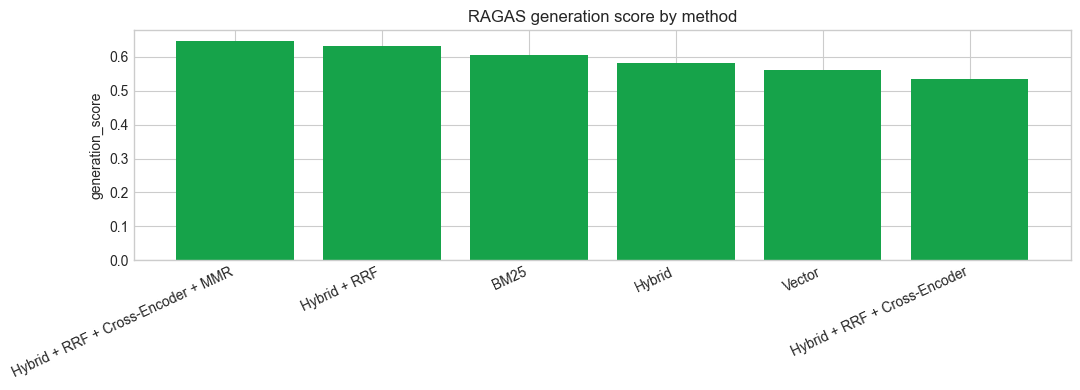

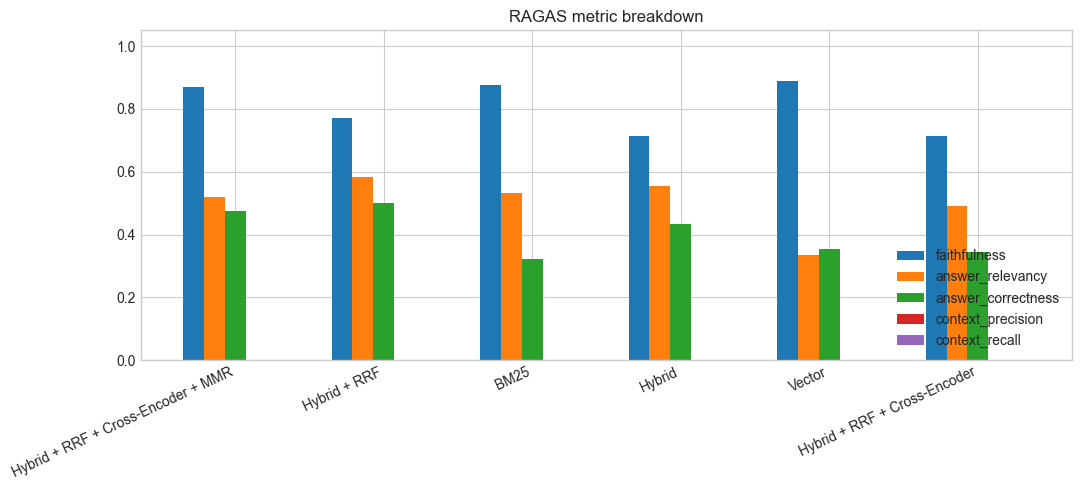

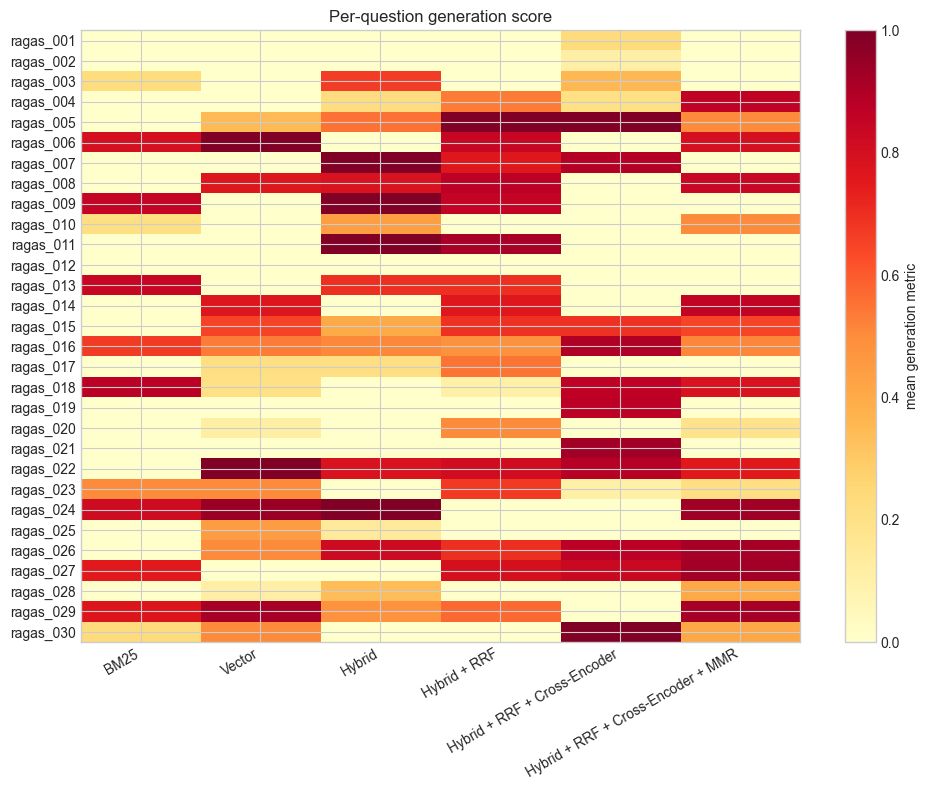

Final selected method: `Hybrid + RRF + Cross-Encoder + MMR`

In [6]:
plt.style.use("seaborn-v0_8-whitegrid")

plot_df = selection_df.copy()
score_values = plot_df["generation_score"].fillna(0.0)
plt.figure(figsize=(11, 4))
plt.bar(plot_df["display_name"], score_values, color="#16a34a")
plt.ylabel("generation_score")
plt.xticks(rotation=25, ha="right")
plt.title("RAGAS generation score by method")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "generation_score.png", dpi=160)
plt.show()

metric_columns = [metric for metric in GENERATION_METRICS + DIAGNOSTIC_CONTEXT_METRICS if metric in plot_df.columns]
metric_plot = plot_df.set_index("display_name")[metric_columns].fillna(0.0)
plt.figure(figsize=(11, 5))
x = np.arange(len(metric_plot.index))
width = 0.14
for idx, metric in enumerate(metric_columns):
    plt.bar(x + idx * width, metric_plot[metric], width=width, label=metric)
plt.xticks(x + width * (len(metric_columns) - 1) / 2, metric_plot.index, rotation=25, ha="right")
plt.ylim(0, 1.05)
plt.legend(loc="lower right")
plt.title("RAGAS metric breakdown")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "generation_metric_breakdown.png", dpi=160)
plt.show()

detail_df = pd.DataFrame(details)
available_generation_cols = [metric for metric in GENERATION_METRICS if metric in detail_df.columns]
if available_generation_cols:
    detail_df["generation_case_mean"] = detail_df[available_generation_cols].mean(axis=1, skipna=True)
    heat = detail_df.pivot(index="question_id", columns="retrieval_method", values="generation_case_mean").loc[:, methods]
    plt.figure(figsize=(10, 8))
    plt.imshow(heat.fillna(0.0).values, aspect="auto", cmap="YlOrRd", vmin=0, vmax=1)
    plt.colorbar(label="mean generation metric")
    plt.xticks(range(len(heat.columns)), [method_labels.get(m, m) for m in heat.columns], rotation=30, ha="right")
    plt.yticks(range(len(heat.index)), heat.index)
    plt.title("Per-question generation score")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "generation_query_heatmap.png", dpi=160)
    plt.show()
else:
    detail_df["generation_case_mean"] = np.nan

weakest = detail_df.sort_values("generation_case_mean", na_position="last").head(10)

lines = [
    "# RAGAS Generation Evaluation and Final Selection",
    "",
    "The table below compares all retrieval methods after answer generation. The final method is selected only by RAGAS generation metrics.",
    "",
    f"- Backend: `{ragas_report['backend']}`",
    f"- Cached metrics used: `{ragas_report.get('metrics_cached', False)}`",
    f"- Answers cached: `{ragas_report.get('answers_cached', False)}`",
    f"- Answers evaluated: `{ragas_report['answer_count']}`",
    f"- Retrieval methods evaluated: `{', '.join(method_labels.get(m, m) for m in ragas_report['retrieval_methods_evaluated'])}`",
    f"- Selected final method: `{ragas_report['selected_display_name']}`",
    f"- Selection metric: `{ragas_report['selection_metric']}`",
    f"- Selection formula: `{ragas_report['selection_formula']}`",
    f"- Retrieval metrics used for selection: `{ragas_report['retrieval_metrics_used_for_selection']}`",
    f"- Generation score note: `{ragas_report['generation_score_note']}`",
    f"- RAGAS context max chars per chunk: `{ragas_report['ragas_context_max_chars']}`",
    "",
    "| Rank | Method | Retrieval score | Faithfulness | Answer relevancy | Answer correctness | Context precision | Context recall | Generation score |",
    "|---:|---|---:|---:|---:|---:|---:|---:|---:|",
]

def fmt(value):
    return "N/A" if value is None or pd.isna(value) else f"{float(value):.3f}"

for rank, row in enumerate(selection_df.to_dict("records"), start=1):
    lines.append(
        f"| {rank} | {row['display_name']} | {fmt(row.get('retrieval_score'))} | {fmt(row.get('faithfulness'))} | "
        f"{fmt(row.get('answer_relevancy'))} | {fmt(row.get('answer_correctness'))} | {fmt(row.get('context_precision'))} | "
        f"{fmt(row.get('context_recall'))} | {fmt(row.get('generation_score'))} |"
    )

lines.extend([
    "",
    "## Metric Coverage",
    "",
    "| Method | Faithfulness n | Answer relevancy n | Answer correctness n |",
    "|---|---:|---:|---:|",
])
for row in selection_df.to_dict("records"):
    method = row["method"]
    counts = ragas_report.get("metric_valid_counts", {}).get(method, {})
    lines.append(
        f"| {row['display_name']} | {counts.get('faithfulness', 0)} | "
        f"{counts.get('answer_relevancy', 0)} | {counts.get('answer_correctness', 0)} |"
    )

lines.extend(["", "## Unavailable Metrics", ""])
if ragas_report.get("unavailable_metrics"):
    for metric in ragas_report["unavailable_metrics"]:
        lines.append(f"- `{metric}`")
else:
    lines.append("- None")

lines.extend([
    "",
    "## Figures",
    "",
    "- `reports/figures/generation_score.png`",
    "- `reports/figures/generation_metric_breakdown.png`",
    "- `reports/figures/generation_query_heatmap.png`",
    "",
    "## Weakest Cases",
    "",
])
for _, row in weakest.iterrows():
    mean_value = fmt(row.get("generation_case_mean"))
    question_text = row.get("question") if "question" in row else row.get("user_input", "")
    lines.append(f"- `{method_labels.get(row['retrieval_method'], row['retrieval_method'])}` - {question_text} - mean={mean_value}")

RAGAS_EVAL_MD.write_text("\n".join(lines) + "\n", encoding="utf-8")
Markdown(f"Final selected method: `{method_labels.get(selected_method, selected_method)}`")
